# RNN Project:Retail Sales Forecasting

## Real World Problem
Hum pichlay **7 din ke multiple features** use karke **aglay din ki sales** predict karenge.

## Dataset Features
- Visitors
- Promotion
- Weekend
- Holiday
- Temperature
- Average Order Value
- Sales

In [1]:
# Table form data ko read aur manage karne ke liye Pandas import kar rahe hain
import pandas as pd  

# Numerical arrays aur calculations ke liye NumPy import kar rahe hain
import numpy as np  

# Graph banane ke liye Matplotlib import kar rahe hain
import matplotlib.pyplot as plt  

# Features ko 0 aur 1 ke darmiyan convert karne ke liye scaler import kar rahe hain
from sklearn.preprocessing import MinMaxScaler 

# Prediction error check karne ke liye MAE metric import kar rahe hain
from sklearn.metrics import mean_absolute_error  

# Deep Learning model banane ke liye TensorFlow import kar rahe hain
import tensorflow as tf 

import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Load Karna

In [2]:
df = pd.read_csv("Session 22 A.csv")  
df

,Date,Visitors,Promotion,Weekend,Holiday,Temperature,Average_Order_Value,Sales
0,1/1/2025,306,0,0,1,26.4,1110.29,401.39
1,1/2/2025,194,0,0,0,24.6,792.90,163.06
2,1/3/2025,227,0,0,0,24.4,966.08,257.94
3,1/4/2025,223,0,1,0,22.7,778.31,218.97
4,1/5/2025,314,0,1,0,23.1,960.03,280.84
...,...,...,...,...,...,...,...,...
360,12/27/2025,279,0,1,0,24.4,849.84,296.94
361,12/28/2025,236,0,1,0,24.6,804.24,248.21
362,12/29/2025,221,0,0,0,21.2,927.64,272.46
363,12/30/2025,206,0,0,0,25.0,888.17,216.08


## 3. Dataset Ki Basic Information

In [3]:
df.dtypes

Date                       str
Visitors                 int64
Promotion                int64
Weekend                  int64
Holiday                  int64
Temperature            float64
Average_Order_Value    float64
Sales                  float64
dtype: object

In [4]:
# Date column ko proper datetime format mein convert kar rahe hain
df["Date"] = pd.to_datetime(df["Date"]) 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 365 non-null    datetime64[us]
 1   Visitors             365 non-null    int64         
 2   Promotion            365 non-null    int64         
 3   Weekend              365 non-null    int64         
 4   Holiday              365 non-null    int64         
 5   Temperature          365 non-null    float64       
 6   Average_Order_Value  365 non-null    float64       
 7   Sales                365 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(4)
memory usage: 22.9 KB


In [6]:
df.isnull().sum()

Date                   0
Visitors               0
Promotion              0
Weekend                0
Holiday                0
Temperature            0
Average_Order_Value    0
Sales                  0
dtype: int64

In [7]:
df['Date']

0     2025-01-01
1     2025-01-02
2     2025-01-03
3     2025-01-04
4     2025-01-05
         ...    
360   2025-12-27
361   2025-12-28
362   2025-12-29
363   2025-12-30
364   2025-12-31
Name: Date, Length: 365, dtype: datetime64[us]

In [8]:
df['Date'].dt.year

0      2025
1      2025
2      2025
3      2025
4      2025
       ... 
360    2025
361    2025
362    2025
363    2025
364    2025
Name: Date, Length: 365, dtype: int32

In [9]:
df['Date'].dt.year.unique()

array([2025], dtype=int32)

In [10]:
df['Date'].dt.month.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [11]:
df['Date'].dt.month_name().unique()

<ArrowStringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [12]:
df['Date'].dt.day_name().unique()

<ArrowStringArray>
['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday']
Length: 7, dtype: str

In [13]:
df['Date'].dt.day

0       1
1       2
2       3
3       4
4       5
       ..
360    27
361    28
362    29
363    30
364    31
Name: Date, Length: 365, dtype: int32

## 4. Daily Sales Ka Graph

*   List item
*   List item



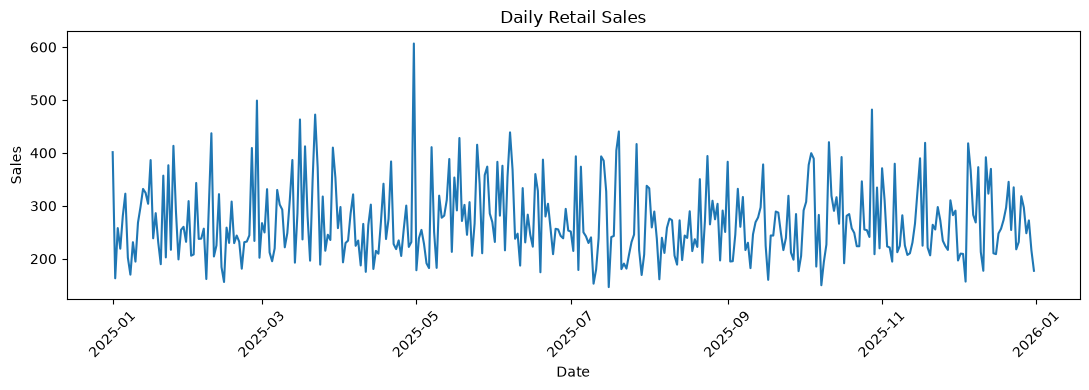

In [14]:
plt.figure(figsize=(11, 4)) 

plt.plot(df["Date"], df["Sales"])

plt.title("Daily Retail Sales") 
plt.xlabel("Date")  
plt.ylabel("Sales")  

# Dates ko rotate kar rahe hain taake clear nazar aayein
plt.xticks(rotation=45)  

# Graph ki spacing automatically adjust kar rahe hain
plt.tight_layout()  

plt.show() 

In [15]:
df.head()

,Date,Visitors,Promotion,Weekend,Holiday,Temperature,Average_Order_Value,Sales
0,2025-01-01,306,0,0,1,26.4,1110.29,401.39
1,2025-01-02,194,0,0,0,24.6,792.90,163.06
2,2025-01-03,227,0,0,0,24.4,966.08,257.94
3,2025-01-04,223,0,1,0,22.7,778.31,218.97
4,2025-01-05,314,0,1,0,23.1,960.03,280.84


In [16]:
df.columns

Index(['Date', 'Visitors', 'Promotion', 'Weekend', 'Holiday', 'Temperature',
       'Average_Order_Value', 'Sales'],
      dtype='str')

## 5. Features Select Aur Normalize Karna

In [17]:
# Model ke liye required features select kar rahe hain
feature_columns = ["Visitors", "Promotion", "Weekend", "Holiday", "Temperature", "Average_Order_Value", "Sales"]

In [18]:
feature_columns

['Visitors',
 'Promotion',
 'Weekend',
 'Holiday',
 'Temperature',
 'Average_Order_Value',
 'Sales']

In [19]:
type(feature_columns)

list

In [20]:
# Input features ke liye scaler object bana rahe hain
feature_scaler = MinMaxScaler()  

# Tamam selected features ko 0 aur 1 ke darmiyan convert kar rahe hain
scaled_features = feature_scaler.fit_transform(df[feature_columns]) 

In [21]:
scaled_features 

array([[0.70212766, 0.        , 0.        , ..., 0.55555556, 0.71243877,
        0.55398153],
       [0.10638298, 0.        , 0.        , ..., 0.48412698, 0.27073592,
        0.03615426],
       [0.28191489, 0.        , 0.        , ..., 0.47619048, 0.51174571,
        0.2423031 ],
       ...,
       [0.25      , 0.        , 0.        , ..., 0.34920635, 0.45824983,
        0.27385117],
       [0.17021277, 0.        , 0.        , ..., 0.5       , 0.40332053,
        0.15135253],
       [0.2393617 , 0.        , 0.        , ..., 0.65873016, 0.31668893,
        0.06707224]], shape=(365, 7))

In [22]:
# Target sales ke liye alag scaler object bana rahe hain
target_scaler = MinMaxScaler() 

# Sales target ko 0 aur 1 ke darmiyan convert kar rahe hain
scaled_target = target_scaler.fit_transform(df[["Sales"]])  
scaled_target

array([[0.55398153],
       [0.03615426],
       [0.2423031 ],
       [0.15763172],
       [0.29205866],
       [0.3836176 ],
       [0.12108637],
       [0.05114612],
       [0.18442151],
       [0.10466051],
       [0.26487778],
       [0.32936448],
       [0.40312873],
       [0.38707224],
       [0.34209669],
       [0.52156437],
       [0.20034764],
       [0.30368278],
       [0.18366105],
       [0.09401412],
       [0.45762086],
       [0.121912  ],
       [0.50031505],
       [0.15315589],
       [0.57998914],
       [0.31065725],
       [0.11365562],
       [0.23491581],
       [0.24758284],
       [0.18587724],
       [0.35313417],
       [0.12899511],
       [0.13418794],
       [0.42761543],
       [0.197849  ],
       [0.19915263],
       [0.24      ],
       [0.03317762],
       [0.33529603],
       [0.6315698 ],
       [0.12577947],
       [0.17101575],
       [0.38170559],
       [0.08212928],
       [0.02105378],
       [0.2442151 ],
       [0.18140141],
       [0.351

## 6. Sequence Banana

Har input sample mein pichlay **7 din ke tamam features** honge.

Target mein **8wein din ki sales** hogi.

In [23]:
len(scaled_features)

365

In [24]:
def create_sequences(features, target, time_steps=7):
    
    # Input sequences store karne ke liye empty list
    X = []

    # Har sequence ki next target value store karne ke liye empty list
    y = []

    # Data par loop chala rahe hain.
    # Agar total rows = 365 aur time_steps = 7 hain,
    # to loop 358 baar chalega (365 - 7 = 358).
    for i in range(len(features) - time_steps):

        # Current row (i) se start karke aglay 7 records
        # ek sequence ki form mein select kar rahe hain.
        #
        # Example:
        # i = 0
        # features[0:7]
        # Rows: 0,1,2,3,4,5,6
        X.append(features[i:i + time_steps])

        # Sequence ke foran baad wali value ko target bana rahe hain.
        #
        # Example:
        # target[7]
        # Row 7 ki Sales
        y.append(target[i + time_steps])

    # Python lists ko NumPy arrays mein convert karke return kar rahe hain
    return np.array(X), np.array(y)

In [25]:
X, y = create_sequences(scaled_features, scaled_target, time_steps=7)  # Features aur target se sequences bana rahe hain
print("X shape:", X.shape)  # Input data ki 3D shape dekh rahe hain
print("y shape:", y.shape)  # Target data ki shape dekh rahe hain

X shape: (358, 7, 7)
y shape: (358, 1)


In [26]:
# (Number of Sequences,
#  Time Steps,
#  Number of Features)

In [27]:
X

array([[[0.70212766, 0.        , 0.        , ..., 0.55555556,
         0.71243877, 0.55398153],
        [0.10638298, 0.        , 0.        , ..., 0.48412698,
         0.27073592, 0.03615426],
        [0.28191489, 0.        , 0.        , ..., 0.47619048,
         0.51174571, 0.2423031 ],
        ...,
        [0.74468085, 0.        , 1.        , ..., 0.42460317,
         0.5033261 , 0.29205866],
        [0.75      , 1.        , 0.        , ..., 0.39285714,
         0.39270207, 0.3836176 ],
        [0.16489362, 0.        , 0.        , ..., 0.32142857,
         0.34240704, 0.12108637]],

       [[0.10638298, 0.        , 0.        , ..., 0.48412698,
         0.27073592, 0.03615426],
        [0.28191489, 0.        , 0.        , ..., 0.47619048,
         0.51174571, 0.2423031 ],
        [0.2606383 , 0.        , 1.        , ..., 0.40873016,
         0.25043142, 0.15763172],
        ...,
        [0.75      , 1.        , 0.        , ..., 0.39285714,
         0.39270207, 0.3836176 ],
        [0.1

In [28]:
y

array([[0.05114612],
       [0.18442151],
       [0.10466051],
       [0.26487778],
       [0.32936448],
       [0.40312873],
       [0.38707224],
       [0.34209669],
       [0.52156437],
       [0.20034764],
       [0.30368278],
       [0.18366105],
       [0.09401412],
       [0.45762086],
       [0.121912  ],
       [0.50031505],
       [0.15315589],
       [0.57998914],
       [0.31065725],
       [0.11365562],
       [0.23491581],
       [0.24758284],
       [0.18587724],
       [0.35313417],
       [0.12899511],
       [0.13418794],
       [0.42761543],
       [0.197849  ],
       [0.19915263],
       [0.24      ],
       [0.03317762],
       [0.33529603],
       [0.6315698 ],
       [0.12577947],
       [0.17101575],
       [0.38170559],
       [0.08212928],
       [0.02105378],
       [0.2442151 ],
       [0.18140141],
       [0.35122216],
       [0.18044541],
       [0.21177621],
       [0.18620315],
       [0.0755459 ],
       [0.18446496],
       [0.18694188],
       [0.212

## 7. Training Aur Testing Data

In [29]:
# Sequence data ka 80 percent training ke liye calculate kar rahe hain
split_index = int(len(X) * 0.80) 

# Shuru ka 80 percent input training ke liye le rahe hain
X_train = X[:split_index]  

# Baqi 20 percent input testing ke liye le rahe hain
X_test = X[split_index:] 

# Shuru ka 80 percent target training ke liye le rahe hain
y_train = y[:split_index]  

# Baqi 20 percent target testing ke liye le rahe hain
y_test = y[split_index:]  

In [30]:
split_index

286

In [31]:
X_train.shape

(286, 7, 7)

In [32]:
y_train.shape

(286, 1)

In [33]:
X_test.shape

(72, 7, 7)

In [34]:
y_test.shape

(72, 1)

In [35]:
X_train

array([[[0.70212766, 0.        , 0.        , ..., 0.55555556,
         0.71243877, 0.55398153],
        [0.10638298, 0.        , 0.        , ..., 0.48412698,
         0.27073592, 0.03615426],
        [0.28191489, 0.        , 0.        , ..., 0.47619048,
         0.51174571, 0.2423031 ],
        ...,
        [0.74468085, 0.        , 1.        , ..., 0.42460317,
         0.5033261 , 0.29205866],
        [0.75      , 1.        , 0.        , ..., 0.39285714,
         0.39270207, 0.3836176 ],
        [0.16489362, 0.        , 0.        , ..., 0.32142857,
         0.34240704, 0.12108637]],

       [[0.10638298, 0.        , 0.        , ..., 0.48412698,
         0.27073592, 0.03615426],
        [0.28191489, 0.        , 0.        , ..., 0.47619048,
         0.51174571, 0.2423031 ],
        [0.2606383 , 0.        , 1.        , ..., 0.40873016,
         0.25043142, 0.15763172],
        ...,
        [0.75      , 1.        , 0.        , ..., 0.39285714,
         0.39270207, 0.3836176 ],
        [0.1

## 8. Simple RNN Model Banana

In [36]:
# Sequential model create kar rahe hain jisme layers ek ke baad ek add hongi
model = tf.keras.Sequential([

    # Simple RNN Layer
    # 32 neurons use ho rahe hain.
    # Input shape = (7, 7)
    # Matlab:
    # 7 Time Steps (Past 7 Days)
    # 7 Features per Day
    tf.keras.layers.SimpleRNN(
        units=32,
        input_shape=(7, 7)
    ),

    # Hidden Dense Layer
    # 16 neurons use ho rahe hain.
    # ReLU activation non-linear patterns seekhne mein madad karti hai.
    tf.keras.layers.Dense(
        units=16,
        activation="relu"
    ),

    # Output Layer
    # Sirf 1 neuron kyun ke model aglay din ki
    # sirf aik Sales value predict karega.
    tf.keras.layers.Dense(1)

])

In [37]:
# Model Compile

model.compile(

    # Adam optimizer weights ko efficiently update karta hai.
    optimizer="adam",

    # Mean Squared Error regression problems ke liye use hota hai.
    loss="mse",

    # Mean Absolute Error training ke dauran performance dikhata hai.
    metrics=["mae"]

)


# Model ki complete architecture aur parameters dekhne ke liye
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,825 (7.13 KB)

 Trainable params: 1,825 (7.13 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Model Train Karna

In [38]:
# Model Training
history = model.fit(

    # Model ko training input data de rahe hain
    X_train,

    # Training ke actual target values
    y_train,

    # Pura training dataset model ko 35 baar dikhaya jayega
    epochs=35,

    # Har training step mein 16 samples process honge
    batch_size=16,

    # Training data ka 20% hissa validation ke liye use hoga
    # Validation data sirf model ki performance check karne ke liye hota hai,
    # is par model training nahi karta.
    validation_split=0.20,

    # Har epoch ke baad training aur validation results screen par show honge
    verbose=1

)

Epoch 1/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.1401 - mae: 0.2932 - val_loss: 0.0347 - val_mae: 0.1449
Epoch 2/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0533 - mae: 0.1800 - val_loss: 0.0508 - val_mae: 0.1909
Epoch 3/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0394 - mae: 0.1511 - val_loss: 0.0302 - val_mae: 0.1392
Epoch 4/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0312 - mae: 0.1414 - val_loss: 0.0386 - val_mae: 0.1590
Epoch 5/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0285 - mae: 0.1306 - val_loss: 0.0289 - val_mae: 0.1357
Epoch 6/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0268 - mae: 0.1256 - val_loss: 0.0279 - val_mae: 0.1332
Epoch 7/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0264 - mae: 0.1296 - val_loss: 0.0353 - val_mae: 0.1493
Epoch 8/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0255 - mae: 0.1235 - val_loss: 0.0275 - val_mae: 0.1328
Epoch 9/35
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0254 - mae:

## 10. Prediction Aur Model Evaluation

In [39]:

# Test dataset par prediction kar rahe hain.
# Ye predictions abhi normalized (scaled) form mein hain.
predictions_scaled = model.predict(X_test)

# Predicted values ko original Sales scale mein convert kar rahe hain.
predictions = target_scaler.inverse_transform(predictions_scaled)

# Actual test Sales values ko bhi original scale mein convert kar rahe hain.
actual_sales = target_scaler.inverse_transform(y_test)

# Actual aur Predicted Sales ke darmiyan
# Mean Absolute Error (MAE) calculate kar rahe hain.
mae = mean_absolute_error(actual_sales, predictions)

# Final MAE ko 2 decimal places ke sath print kar rahe hain.
print("Mean Absolute Error:", round(mae, 2))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Mean Absolute Error: 61.55


In [40]:
predictions_scaled

array([[ 0.23530391],
       [ 0.3030669 ],
       [ 0.20367734],
       [ 0.12980337],
       [ 0.4234537 ],
       [ 0.2411877 ],
       [ 0.14063458],
       [ 0.10442929],
       [ 0.16975796],
       [ 0.4324807 ],
       [ 0.1547015 ],
       [ 0.32224387],
       [ 0.40046993],
       [ 0.22671889],
       [-0.01985545],
       [ 0.18027644],
       [ 0.21295123],
       [ 0.2116477 ],
       [ 0.31761906],
       [ 0.0527916 ],
       [ 0.10683087],
       [ 0.15363148],
       [ 0.20497508],
       [ 0.31824723],
       [ 0.18830217],
       [ 0.28406048],
       [ 0.3379183 ],
       [-0.01340319],
       [ 0.0626185 ],
       [ 0.0943399 ],
       [ 0.34718132],
       [ 0.22094658],
       [ 0.35039148],
       [ 0.29670206],
       [ 0.21021104],
       [ 0.14377713],
       [ 0.27560648],
       [ 0.21685185],
       [ 0.02704154],
       [ 0.44243753],
       [ 0.3688965 ],
       [ 0.20270042],
       [ 0.09606208],
       [ 0.2971238 ],
       [ 0.23272803],
       [ 0

In [41]:
predictions

array([[254.71864],
       [285.90656],
       [240.1625 ],
       [206.162  ],
       [341.31454],
       [257.42664],
       [211.14706],
       [194.48358],
       [224.5511 ],
       [345.46924],
       [217.62137],
       [294.73273],
       [330.7363 ],
       [250.76738],
       [137.28154],
       [229.39224],
       [244.4308 ],
       [243.83084],
       [292.6042 ],
       [170.71733],
       [195.5889 ],
       [217.12889],
       [240.75978],
       [292.8933 ],
       [233.08607],
       [277.15884],
       [301.94693],
       [140.25119],
       [175.24016],
       [189.83994],
       [306.2102 ],
       [248.11067],
       [307.68768],
       [282.97714],
       [243.16963],
       [212.59343],
       [273.26788],
       [246.22606],
       [158.86588],
       [350.05188],
       [316.20462],
       [239.71288],
       [190.63258],
       [283.17123],
       [253.5331 ],
       [211.77571],
       [244.2914 ],
       [356.85965],
       [ 83.05863],
       [219.15901],


## 11. Actual Aur Predicted Sales Table

In [42]:
# Actual vs Predicted Sales Comparison
# Actual aur Predicted Sales ko ek DataFrame mein store kar rahe hain
result = pd.DataFrame({

    # Actual test Sales values
    "Actual Sales": actual_sales.flatten(),

    # Model ki predicted Sales values
    "Predicted Sales": predictions.flatten()

})

# Pehli 10 rows ko 2 decimal places ke sath display kar rahe hain
result

,Actual Sales,Predicted Sales
0,248.81,254.718643
1,223.68,285.906555
2,223.62,240.162506
3,346.28,206.162003
4,255.24,341.314545
...,...,...
67,296.94,346.289124
68,248.21,376.220093
69,272.46,270.756866
70,216.08,259.346161


## 12. Actual Vs Predicted Graph

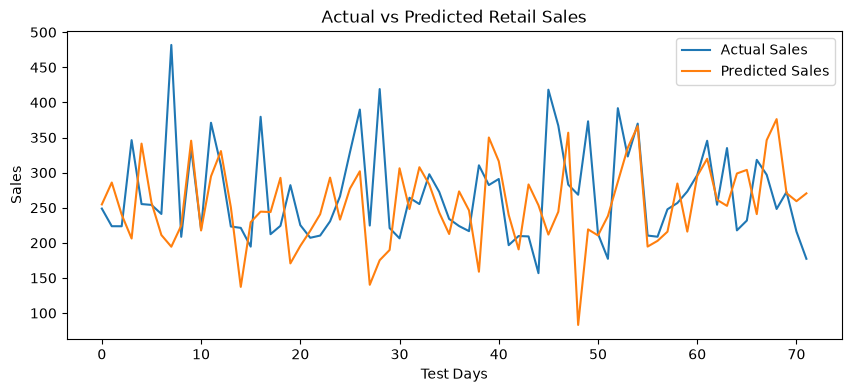

In [43]:
plt.figure(figsize=(10, 4))  # Comparison graph ka size set kar rahe hain
plt.plot(actual_sales, label="Actual Sales")  # Actual sales ki line plot kar rahe hain
plt.plot(predictions, label="Predicted Sales")  # Predicted sales ki line plot kar rahe hain
plt.title("Actual vs Predicted Retail Sales")  # Graph ka title set kar rahe hain
plt.xlabel("Test Days")  # X-axis ko test days ka naam de rahe hain
plt.ylabel("Sales")  # Y-axis ko sales ka naam de rahe hain
plt.legend()  # Dono lines ke labels show kar rahe hain
plt.show()  # Final graph display kar rahe hain

## 13. Agalay Din Ki Sales Predict Karna

In [48]:
# Next Day Sales Prediction
# Dataset ke last 7 din ke input features select kar rahe hain
last_7_days = scaled_features[-7:]

# Input data ko RNN ki required 3D shape mein convert kar rahe hain
# Shape: (Samples, Time Steps, Features)
# (1, 7, 7) = 1 Sequence, 7 Days, 7 Features
last_7_days = last_7_days.reshape(1, 7, 7)

# Last 7 din ke pattern ki basis par
# aglay din ki Sales predict kar rahe hain
next_day_scaled = model.predict(last_7_days)

# Predicted Sales ko normalized scale se
# original Sales scale mein convert kar rahe hain
next_day_sales = target_scaler.inverse_transform(next_day_scaled)

# Aglay din ki final predicted Sales display kar rahe hain
print("Next Day Predicted Sales:", round(next_day_sales[0][0], 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Next Day Predicted Sales: 244.51


In [49]:
print(next_day_sales)

[[244.51245]]


## Project Summary

Is project mein model sirf purani sales nahi dekhta, balke:

- Visitors
- Promotion
- Weekend
- Holiday
- Temperature
- Average Order Value
- Previous Sales

sab ko use karke next day sales predict karta hai.


